In [ ]:
!pip install -U pandas numpy scikit-learn matplotlib datasets transformers torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19

In [ ]:
!pip -q install -U "transformers>=4.45" "datasets>=2.18" accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 13.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.


In [2]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd


ds = load_dataset("go_emotions")
df = ds["train"].to_pandas()


df = df.sample(n=15000, random_state=42).reset_index(drop=True)


emotion_names = ds["train"].features["labels"].feature.names
def dominant_emotion(lbls):
    return emotion_names[lbls[0]] if len(lbls) else "neutral"

df["dominant_emotion"] = [dominant_emotion(lbls) for lbls in df["labels"]]

pos = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}

def emotion_to_sentiment(e):
    if e in pos: return "positive"
    if e in neg: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emotion_to_sentiment)

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["sentiment_label"])
train_df, val_df  = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["sentiment_label"])
val_df["label"]   = le.transform(val_df["sentiment_label"])
test_df["label"]  = le.transform(test_df["sentiment_label"])


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Train: 9600, Val: 2400, Test: 3000


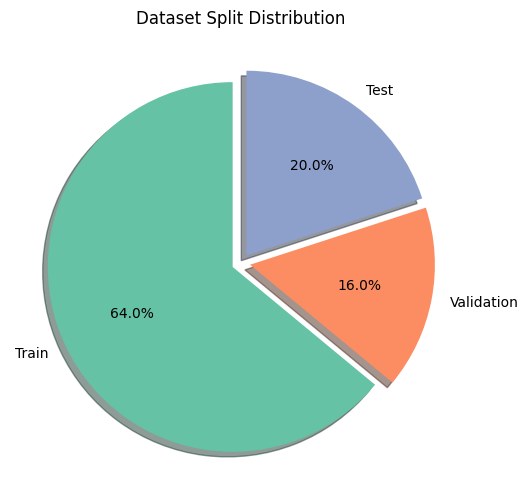

In [5]:
import matplotlib.pyplot as plt

#RoBERTa
splits = ['Train', 'Validation', 'Test']
sizes = [9600, 2400, 3000]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=splits, autopct='%1.1f%%', colors=['#66c2a5','#fc8d62','#8da0cb'],
        startangle=90, explode=(0.05,0.05,0.05), shadow=True)
plt.title('Dataset Split Distribution')
plt.show()


In [3]:
import transformers, datasets
print(transformers.__version__, datasets.__version__)


4.57.1 4.0.0


/tmp/ipython-input-1470314505.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


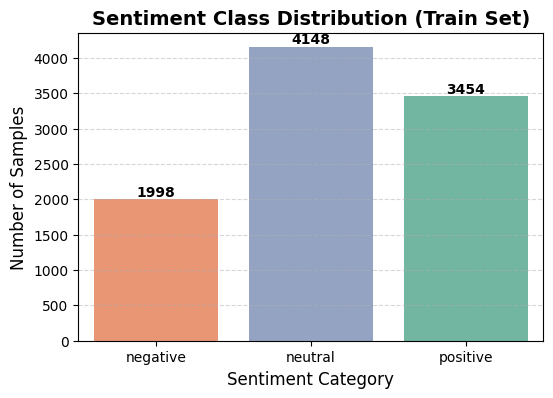

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(
    x="sentiment_label",
    data=train_df,
    order=["negative", "neutral", "positive"],
    palette=["#fc8d62", "#8da0cb", "#66c2a5"]
)

plt.title("Sentiment Class Distribution (Train Set)", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Category", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)


for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2,
             p.get_height() + 50,
             f'{int(p.get_height())}',
             ha='center', fontsize=10, fontweight='bold')

plt.show()

In [7]:
!pip -q install -U "datasets>=2.18"

In [8]:
import transformers, datasets
print(transformers.__version__, datasets.__version__)

4.57.1 4.0.0


In [ ]:
import transformers, datasets
print(transformers.__version__, datasets.__version__)

4.57.1 4.4.1


In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd


ds = load_dataset("go_emotions")
df = ds["train"].to_pandas()


df = df.sample(n=2000, random_state=42).reset_index(drop=True)


emotion_names = ds["train"].features["labels"].feature.names

def dominant_emotion(lbls):
    return emotion_names[lbls[0]] if len(lbls) else "neutral"

df["dominant_emotion"] = [dominant_emotion(lbls) for lbls in df["labels"]]

pos_set = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg_set = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}

def emotion_to_sentiment(e):
    if e in pos_set: return "positive"
    if e in neg_set: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emotion_to_sentiment)

train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["sentiment_label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"]
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(df["sentiment_label"].value_counts())


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Train: 1280, Val: 320, Test: 400
sentiment_label
neutral     859
positive    730
negative    411
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
train_df["label"] = le.fit_transform(train_df["sentiment_label"])
val_df["label"]   = le.transform(val_df["sentiment_label"])
test_df["label"]  = le.transform(test_df["sentiment_label"])

In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd


ds = load_dataset("go_emotions")
df = ds["train"].to_pandas()


df = df.sample(n=2000, random_state=42).reset_index(drop=True)


emotion_names = ds["train"].features["labels"].feature.names

def dominant_emotion(lbls):
    return emotion_names[lbls[0]] if len(lbls) else "neutral"

df["dominant_emotion"] = [dominant_emotion(lbls) for lbls in df["labels"]]

pos_set = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg_set = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}

def emotion_to_sentiment(e):
    if e in pos_set: return "positive"
    if e in neg_set: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emotion_to_sentiment)


train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["sentiment_label"])
train_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Train: 1280, Val: 320, Test: 400


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["sentiment_label"])
val_df["label"] = le.transform(val_df["sentiment_label"])
test_df["label"] = le.transform(test_df["sentiment_label"])

print("Label classes:", list(le.classes_))

Label classes: ['negative', 'neutral', 'positive']


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np, torch

model_name = "distilroberta-base"
tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)

hf_train = Dataset.from_pandas(train_df[["text","label"]])
hf_val   = Dataset.from_pandas(val_df[["text","label"]])
hf_test  = Dataset.from_pandas(test_df[["text","label"]])

def tok_batch(b):
    e = tok(b["text"], padding="max_length", truncation=True, max_length=96)
    e["labels"] = b["label"]
    return e

hf_train = hf_train.map(tok_batch, batched=True)
hf_val   = hf_val.map(tok_batch, batched=True)
hf_test  = hf_test.map(tok_batch, batched=True)

hf_train.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
hf_val.set_format(type="torch",   columns=["input_ids","attention_mask","labels"])
hf_test.set_format(type="torch",  columns=["input_ids","attention_mask","labels"])

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

def metrics(pred):
    logits, labels = pred
    yhat = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, yhat), "f1_macro": f1_score(labels, yhat, average="macro")}

args = TrainingArguments(
    output_dir="roberta_reddit_finetune",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    logging_steps=50,
    report_to=[],
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=metrics,
)

trainer.train()

print("Validation:", trainer.evaluate(hf_val))
print("Test:", trainer.evaluate(hf_test))

pred_logits = trainer.predict(hf_test).predictions
pred_labels = pred_logits.argmax(axis=1)
true_labels = test_df["label"].to_numpy()
print(classification_report(true_labels, pred_labels, target_names=sorted(df["sentiment_label"].unique())))


Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3412572344.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,1.040100
100,0.860600
150,0.668800


Validation: {'eval_loss': 0.7203410863876343, 'eval_accuracy': 0.690625, 'eval_f1_macro': 0.6786012774399066, 'eval_runtime': 0.3146, 'eval_samples_per_second': 1017.194, 'eval_steps_per_second': 31.787, 'epoch': 2.0}
Test: {'eval_loss': 0.7629385590553284, 'eval_accuracy': 0.6775, 'eval_f1_macro': 0.6710652533975522, 'eval_runtime': 0.294, 'eval_samples_per_second': 1360.696, 'eval_steps_per_second': 44.223, 'epoch': 2.0}
              precision    recall  f1-score   support

    negative       0.56      0.70      0.62        82
     neutral       0.68      0.68      0.68       172
    positive       0.76      0.66      0.71       146

    accuracy                           0.68       400
   macro avg       0.67      0.68      0.67       400
weighted avg       0.69      0.68      0.68       400



In [ ]:
args.num_train_epochs = 4


In [ ]:
e = tok(b["text"], padding="max_length", truncation=True, max_length=128)

NameError: name 'b' is not defined

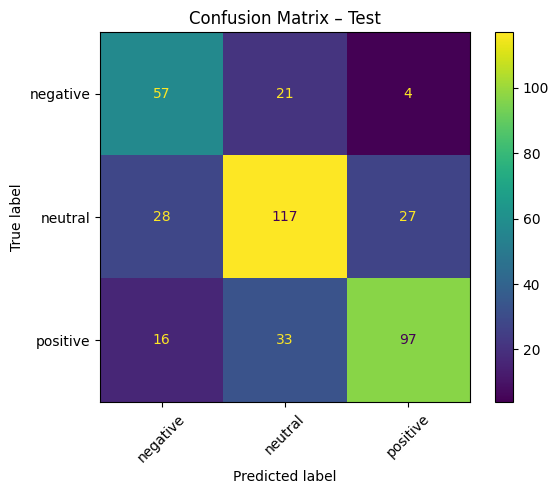

In [ ]:
trainer.save_model("distilroberta_reddit_sentiment")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt, numpy as np
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(df["sentiment_label"].unique()))
disp.plot(xticks_rotation=45); plt.title("Confusion Matrix – Test"); plt.show()

In [ ]:

maxn = train_df["sentiment_label"].value_counts().max()
train_bal = (
    train_df.groupby("sentiment_label", group_keys=False)
            .apply(lambda x: x.sample(maxn, replace=True, random_state=42))
            .reset_index(drop=True)
)


train_bal["label"] = le.transform(train_bal["sentiment_label"])


/tmp/ipython-input-652017408.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(maxn, replace=True, random_state=42))


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np, torch

model_name = "roberta-base"
tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)

hf_train = Dataset.from_pandas(train_bal[["text","label"]])
hf_val   = Dataset.from_pandas(val_df[["text","label"]])
hf_test  = Dataset.from_pandas(test_df[["text","label"]])

def tok_batch(b):
    e = tok(b["text"], padding="max_length", truncation=True, max_length=160)
    e["labels"] = b["label"]
    return e

hf_train = hf_train.map(tok_batch, batched=True)
hf_val   = hf_val.map(tok_batch, batched=True)
hf_test  = hf_test.map(tok_batch, batched=True)

hf_train.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
hf_val.set_format(type="torch",   columns=["input_ids","attention_mask","labels"])
hf_test.set_format(type="torch",  columns=["input_ids","attention_mask","labels"])

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

def metrics(pred):
    logits, labels = pred
    yhat = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, yhat), "f1_macro": f1_score(labels, yhat, average="macro")}

args = TrainingArguments(
    output_dir="roberta_base_balanced",
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    logging_steps=50,
    report_to=[],
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=metrics,
)

trainer.train()
print("Validation:", trainer.evaluate(hf_val))
print("Test:", trainer.evaluate(hf_test))

pred_logits = trainer.predict(hf_test).predictions
pred_labels = pred_logits.argmax(axis=1)
true_labels = test_df["label"].to_numpy()
print(classification_report(true_labels, pred_labels, target_names=sorted(df["sentiment_label"].unique())))


Map:   0%|          | 0/1650 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-506733219.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,1.101600
100,0.818900
150,0.544300
200,0.409100
250,0.283400
300,0.258800
350,0.224000
400,0.136000


Validation: {'eval_loss': 1.0236971378326416, 'eval_accuracy': 0.71875, 'eval_f1_macro': 0.7068937380810718, 'eval_runtime': 0.6775, 'eval_samples_per_second': 472.319, 'eval_steps_per_second': 14.76, 'epoch': 4.0}
Test: {'eval_loss': 1.0509108304977417, 'eval_accuracy': 0.7025, 'eval_f1_macro': 0.694122010833003, 'eval_runtime': 0.7774, 'eval_samples_per_second': 514.531, 'eval_steps_per_second': 16.722, 'epoch': 4.0}
              precision    recall  f1-score   support

    negative       0.57      0.71      0.63        82
     neutral       0.74      0.63      0.68       172
    positive       0.75      0.78      0.77       146

    accuracy                           0.70       400
   macro avg       0.69      0.71      0.69       400
weighted avg       0.71      0.70      0.70       400



In [ ]:
!pip -q install -U transformers accelerate
import torch, numpy as np, pandas as pd, re
print("GPU:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


GPU: True Tesla T4


In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

ds = load_dataset("go_emotions")
df = ds["train"].to_pandas().sample(n=5000, random_state=42).reset_index(drop=True)

emotion_names = ds["train"].features["labels"].feature.names
def dominant(lbls): return emotion_names[lbls[0]] if len(lbls) else "neutral"
df["dominant_emotion"] = [dominant(x) for x in df["labels"]]

pos = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}
def emo2sent(e):
    if e in pos: return "positive"
    if e in neg: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emo2sent)

def clean(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+","", t)
    t = re.sub(r"@[A-Za-z0-9_]+","", t)
    t = t.replace("#","").strip()
    return t
df["text"] = df["text"].apply(clean)


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["sentiment_label"])
train_df, val_df  = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"])
print(len(train_df), len(val_df), len(test_df), train_df["sentiment_label"].value_counts())


3200 800 1000 sentiment_label
neutral     1386
positive    1169
negative     645
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

maxn = train_df["sentiment_label"].value_counts().max()
train_bal = (train_df.groupby("sentiment_label", group_keys=False)
             .apply(lambda x: x.sample(maxn, replace=True, random_state=42))
             .reset_index(drop=True))

le = LabelEncoder()
le.fit(df["sentiment_label"])
train_bal["label"] = le.transform(train_bal["sentiment_label"])
val_df["label"]    = le.transform(val_df["sentiment_label"])
test_df["label"]   = le.transform(test_df["sentiment_label"])

print("Classes:", list(le.classes_), " | Train_bal:", len(train_bal))


Classes: ['negative', 'neutral', 'positive']  | Train_bal: 4158


/tmp/ipython-input-3631957588.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(maxn, replace=True, random_state=42))


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "microsoft/deberta-v3-base"
tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)

hf_train = Dataset.from_pandas(train_bal[["text","label"]])
hf_val   = Dataset.from_pandas(val_df[["text","label"]])
hf_test  = Dataset.from_pandas(test_df[["text","label"]])

def tok_batch(b):
    e = tok(b["text"], padding="max_length", truncation=True, max_length=192)
    e["labels"] = b["label"]
    return e

hf_train = hf_train.map(tok_batch, batched=True)
hf_val   = hf_val.map(tok_batch, batched=True)
hf_test  = hf_test.map(tok_batch, batched=True)

hf_train.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
hf_val.set_format(type="torch",   columns=["input_ids","attention_mask","labels"])
hf_test.set_format(type="torch",  columns=["input_ids","attention_mask","labels"])


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/4158 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch import nn

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

y_train = train_bal["label"].to_numpy()
counts = np.bincount(y_train, minlength=3).astype(np.float32)
weights = (counts.sum() / (3*counts + 1e-9))
class_w = torch.tensor(weights, device="cuda" if torch.cuda.is_available() else "cpu")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = nn.CrossEntropyLoss(weight=class_w)
        loss = loss_fct(outputs.logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def metrics(pred):
    logits, labels = pred
    yhat = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, yhat), "f1_macro": f1_score(labels, yhat, average="macro")}


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
args = TrainingArguments(
    output_dir="deberta_maxpush",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,   # if OOM -> 8
    per_device_eval_batch_size=32,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=50,
    report_to=[],
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=metrics,
)

trainer.train()
print("Validation:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_val).items()})
print("Test:",        {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_test).items()})


/tmp/ipython-input-3889997157.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


TypeError: WeightedTrainer.compute_loss() got an unexpected keyword argument 'num_items_in_batch'

In [ ]:
args = TrainingArguments(
    output_dir="deberta_maxpush",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,   # if OOM -> 8
    per_device_eval_batch_size=32,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=50,
    report_to=[],
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=metrics,
)

trainer.train()
print("Validation:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_val).items()})
print("Test:",        {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_test).items()})

/tmp/ipython-input-2725178755.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


TypeError: WeightedTrainer.compute_loss() got an unexpected keyword argument 'num_items_in_batch'

In [ ]:
import torch
from torch import nn
from transformers import Trainer


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs["labels"]

        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_w)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=metrics,
)

trainer.train()
print("Validation:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_val).items()})
print("Test:",        {k: (round(v,4) if isinstance(v,float) else v) for k,v in trainer.evaluate(hf_test).items()})


/tmp/ipython-input-2833250051.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


{'loss': 1.1103, 'grad_norm': 1.0446089506149292, 'learning_rate': 1.2564102564102565e-05, 'epoch': 0.19230769230769232}
{'loss': 1.037, 'grad_norm': 5.879369735717773, 'learning_rate': 1.965630114566285e-05, 'epoch': 0.38461538461538464}
{'loss': 0.8532, 'grad_norm': 7.205898284912109, 'learning_rate': 1.8837970540098202e-05, 'epoch': 0.5769230769230769}
{'loss': 0.6799, 'grad_norm': 7.365686893463135, 'learning_rate': 1.8019639934533554e-05, 'epoch': 0.7692307692307693}
{'loss': 0.5839, 'grad_norm': 9.584818840026855, 'learning_rate': 1.7201309328968906e-05, 'epoch': 0.9615384615384616}
{'loss': 0.4559, 'grad_norm': 7.143345832824707, 'learning_rate': 1.6382978723404255e-05, 'epoch': 1.1538461538461537}
{'loss': 0.4786, 'grad_norm': 8.965428352355957, 'learning_rate': 1.5564648117839608e-05, 'epoch': 1.3461538461538463}
{'loss': 0.4303, 'grad_norm': 3.5239031314849854, 'learning_rate': 1.4746317512274962e-05, 'epoch': 1.5384615384615383}
{'loss': 0.4338, 'grad_norm': 8.21836090087890

In [ ]:
trainer.save_model("deberta_maxpush")
tok.save_pretrained("deberta_maxpush")


('deberta_maxpush/tokenizer_config.json',
 'deberta_maxpush/special_tokens_map.json',
 'deberta_maxpush/spm.model',
 'deberta_maxpush/added_tokens.json',
 'deberta_maxpush/tokenizer.json')

In [ ]:
from transformers import pipeline
clf = pipeline("text-classification", model="deberta_maxpush", tokenizer="deberta_maxpush", return_all_scores=False)
print(clf("I absolutely love this update!"))


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[{'label': 'LABEL_2', 'score': 0.9988521337509155}]


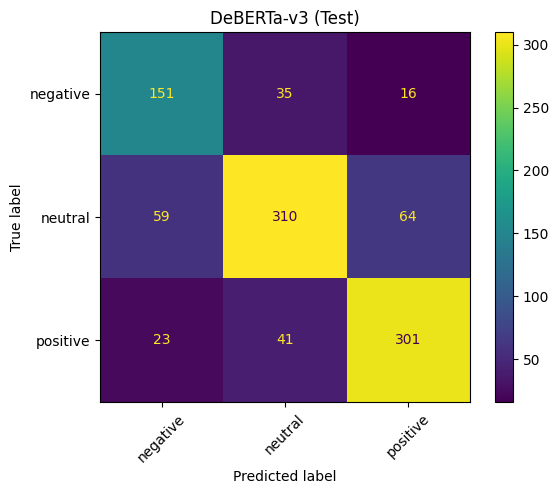

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt, numpy as np
pred_logits = trainer.predict(hf_test).predictions
pred_labels = pred_logits.argmax(axis=1)
true_labels = test_df["label"].to_numpy()
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=list(le.classes_))
disp.plot(xticks_rotation=45); plt.title("DeBERTa-v3 (Test)"); plt.show()


In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()


In [ ]:
import transformers, logging
transformers.logging.set_verbosity_error()
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)


In [ ]:
!pip -q install -U "datasets>=2.18"

In [ ]:
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
from transformers import pipeline


GoEmotions, small sample


In [ ]:
from datasets import load_dataset

ds = load_dataset("go_emotions")
df = ds["train"].to_pandas()

df = df.sample(n=2000, random_state=42).reset_index(drop=True)

emotions = ds["train"].features["labels"].feature.names

def dominant_emotion(label_ids):
    return emotions[label_ids[0]] if len(label_ids) else "neutral"

df["dominant_emotion"] = [dominant_emotion(lbls) for lbls in df["labels"]]
df[["text","dominant_emotion"]].head()

,text,dominant_emotion
0,The only way this works is if [NAME] is doing ...,neutral
1,Access should be hindered it's getting destroyed.,annoyance
2,Totally fair. All I was trying to remind every...,approval
3,"I'm poly and jn the Raleigh area too, moved he...",surprise
4,Naw man Asain men have an easier time. Most of...,amusement


3 class sentiments


In [ ]:
pos_set = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg_set = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}

def emotion_to_sentiment(e):
    if e in pos_set: return "positive"
    if e in neg_set: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emotion_to_sentiment)
df["sentiment_label"].value_counts()


,count
sentiment_label,
neutral,859
positive,730
negative,411


Train/Val/Test split


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["sentiment_label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"]
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Test distribution:\n", test_df["sentiment_label"].value_counts(normalize=True).round(3))

Train: 1280 Val: 320 Test: 400
Test distribution:
 sentiment_label
neutral     0.430
positive    0.365
negative    0.205
Name: proportion, dtype: float64


TF-IDF + Logistic Regression


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

X_train, y_train = train_df["text"], train_df["sentiment_label"]
X_val,   y_val   = val_df["text"],   val_df["sentiment_label"]
X_test,  y_test  = test_df["text"],  test_df["sentiment_label"]

vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9)
Xtr = vec.fit_transform(X_train)
Xv  = vec.transform(X_val)
Xt  = vec.transform(X_test)

clf = LogisticRegression(max_iter=200, class_weight="balanced")
clf.fit(Xtr, y_train)

pred_val  = clf.predict(Xv)
pred_test = clf.predict(Xt)

def report(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"{title}  Accuracy={acc:.3f}  F1-macro={f1m:.3f}")
    print(classification_report(y_true, y_pred))

report(y_val,  pred_val,  "Validation:")
report(y_test, pred_test, "Test:")

Validation:  Accuracy=0.581  F1-macro=0.555
              precision    recall  f1-score   support

    negative       0.37      0.42      0.39        66
     neutral       0.63      0.62      0.62       137
    positive       0.67      0.62      0.65       117

    accuracy                           0.58       320
   macro avg       0.56      0.56      0.56       320
weighted avg       0.59      0.58      0.59       320

Test:  Accuracy=0.560  F1-macro=0.540
              precision    recall  f1-score   support

    negative       0.34      0.45      0.39        82
     neutral       0.60      0.58      0.59       172
    positive       0.70      0.60      0.64       146

    accuracy                           0.56       400
   macro avg       0.55      0.54      0.54       400
weighted avg       0.58      0.56      0.57       400



In [17]:
true_counts = pd.Series(y_test).value_counts().reindex(["negative","neutral","positive"], fill_value=0)

plt.figure(figsize=(6,4))
bars = plt.bar(true_counts.index, true_counts.values, color=["#fc8d62", "#8da0cb", "#66c2a5"])
plt.title("True Sentiment Distribution (Test Set)", fontsize=14, fontweight='bold')
plt.ylabel("Number of Comments")
plt.grid(axis="y", linestyle="--", alpha=0.5)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

Confusion matrix

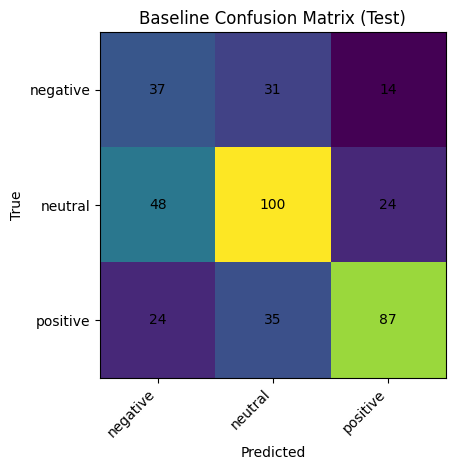

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

labels = sorted(df["sentiment_label"].unique())
cm = confusion_matrix(y_test, pred_test, labels=labels)

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Baseline Confusion Matrix (Test)")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show(); plt.close()

LLM sentiment - RoBERTa

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

sent_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1  # CPU for stability
)

texts = test_df["text"].tolist()[:400]
preds = sent_pipe(texts)

def norm_cardiff(lbl):
    l = lbl.lower()
    if "neg" in l: return "negative"
    if "neu" in l: return "neutral"
    return "positive"

pred_test_cardiff = [norm_cardiff(p["label"]) for p in preds]

print("RoBERTa (CardiffNLP) on test subset:")
print("Accuracy:", round(accuracy_score(y_test[:len(pred_test_cardiff)], pred_test_cardiff),3))
print("F1-macro:", round(f1_score(y_test[:len(pred_test_cardiff)], pred_test_cardiff, average='macro'),3))
print(classification_report(y_test[:len(pred_test_cardiff)], pred_test_cardiff))

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


RoBERTa (CardiffNLP) on test subset:
Accuracy: 0.613
F1-macro: 0.613
              precision    recall  f1-score   support

    negative       0.44      0.91      0.60        82
     neutral       0.72      0.46      0.56       172
    positive       0.75      0.62      0.68       146

    accuracy                           0.61       400
   macro avg       0.64      0.67      0.61       400
weighted avg       0.67      0.61      0.61       400



In [ ]:
emotion_pipe = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=False
)

sample_texts = test_df["text"].tolist()[:10]
results = emotion_pipe(sample_texts)
for t, r in zip(sample_texts, results):
    print(f"\nText: {t[:80]}...")
    print(f"Predicted emotion: {r['label']} (score={r['score']:.2f})")


Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(



Text: The problem is that people cannot differentiate between a necessary and a suffic...
Predicted emotion: neutral (score=0.88)

Text: I'd like to apologize on behalf of all Azwel mains....
Predicted emotion: sadness (score=0.93)

Text: to be fair it wouldnt be bad living there since its normal to have giant shoes s...
Predicted emotion: joy (score=0.65)

Text: Then your education must have been pretty poor lol...
Predicted emotion: neutral (score=0.58)

Text: I work in customer service, so it's inevitable....
Predicted emotion: neutral (score=0.85)

Text: This is me and my wife. She squeals with delight whenever it snows and I start l...
Predicted emotion: joy (score=0.53)

Text: **Flair *does* check out....
Predicted emotion: neutral (score=0.90)

Text: She has at least 12 elbows and all of them are happy. You get it gurl...
Predicted emotion: joy (score=0.81)

Text: Hope you're ok!...
Predicted emotion: neutral (score=0.59)

Text: Holy hell, that sub is nice....
Predicted emotion

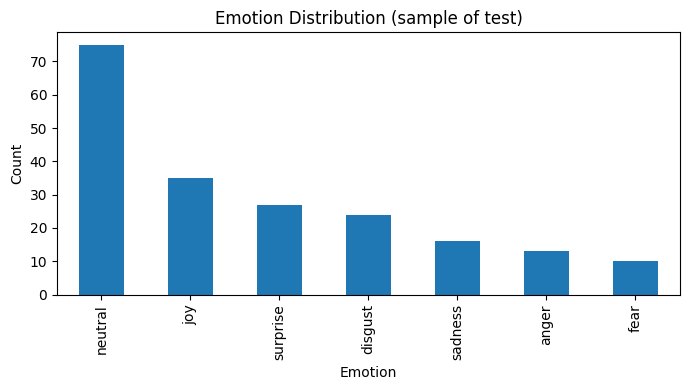

In [ ]:
texts = test_df["text"].tolist()[:200]
preds = emotion_pipe(texts)
emotions_pred = [p["label"] for p in preds]

import pandas as pd
counts = pd.Series(emotions_pred).value_counts()

plt.figure(figsize=(7,4))
counts.plot(kind="bar")
plt.title("Emotion Distribution (sample of test)")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.tight_layout(); plt.show(); plt.close()

Emotion model (fine-grained emotions)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Class counts:
 sentiment_label
neutral     859
positive    730
negative    411
Name: count, dtype: int64 

Train=1280  Val=320  Test=400
Test distribution:
 sentiment_label
neutral     0.430
positive    0.365
negative    0.205
Name: proportion, dtype: float64 

=== BASELINE (TF-IDF + Logistic Regression) ===
Validation:  Accuracy=0.581  F1-macro=0.555
Test:  Accuracy=0.560  F1-macro=0.540

Classification report (Test):
               precision    recall  f1-score   support

    negative       0.34      0.45      0.39        82
     neutral       0.60      0.58      0.59       172
    positive       0.70      0.60      0.64       146

    accuracy                           0.56       400
   macro avg       0.55      0.54      0.54       400
weighted avg       0.58      0.56      0.57       400



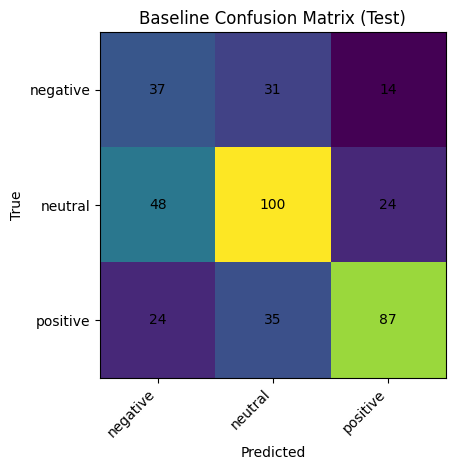


=== FINE-TUNE RoBERTa ON REDDIT (3 classes) ===


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
os.environ["TOKENIZERS_PARALLELISM"] = "false"
random.seed(42); np.random.seed(42)

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)


ds = load_dataset("go_emotions")   # downloads once, then caches
df = ds["train"].to_pandas()

df = df.sample(n=2000, random_state=42).reset_index(drop=True)

emotion_names = ds["train"].features["labels"].feature.names

def dominant_emotion(label_ids):
    return emotion_names[label_ids[0]] if len(label_ids) else "neutral"

df["dominant_emotion"] = [dominant_emotion(lbls) for lbls in df["labels"]]


pos_set = {"joy","admiration","approval","gratitude","love","optimism","relief","pride","amusement","excitement"}
neg_set = {"anger","annoyance","disapproval","disappointment","disgust","embarrassment","fear","grief","remorse","sadness","nervousness"}

def emotion_to_sentiment(e):
    if e in pos_set: return "positive"
    if e in neg_set: return "negative"
    return "neutral"

df["sentiment_label"] = df["dominant_emotion"].apply(emotion_to_sentiment)

print("Class counts:\n", df["sentiment_label"].value_counts(), "\n")


train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["sentiment_label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.20, random_state=42, stratify=train_df["sentiment_label"]
)

print(f"Train={len(train_df)}  Val={len(val_df)}  Test={len(test_df)}")
print("Test distribution:\n", test_df["sentiment_label"].value_counts(normalize=True).round(3), "\n")


print("=== BASELINE (TF-IDF + Logistic Regression) ===")
X_train, y_train = train_df["text"], train_df["sentiment_label"]
X_val,   y_val   = val_df["text"],   val_df["sentiment_label"]
X_test,  y_test  = test_df["text"],  test_df["sentiment_label"]

vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9)
Xtr = vec.fit_transform(X_train)
Xv  = vec.transform(X_val)
Xt  = vec.transform(X_test)

clf = LogisticRegression(max_iter=200, class_weight="balanced")
clf.fit(Xtr, y_train)

pred_val  = clf.predict(Xv)
pred_test = clf.predict(Xt)

def brief_report(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"{title}  Accuracy={acc:.3f}  F1-macro={f1m:.3f}")

brief_report(y_val,  pred_val,  "Validation:")
brief_report(y_test, pred_test, "Test:")

print("\nClassification report (Test):\n", classification_report(y_test, pred_test))


labels_sorted = sorted(df["sentiment_label"].unique())
cm = confusion_matrix(y_test, pred_test, labels=labels_sorted)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Baseline Confusion Matrix (Test)")
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
plt.yticks(range(len(labels_sorted)), labels_sorted)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show(); plt.close()

print("\n=== FINE-TUNE RoBERTa ON REDDIT (3 classes) ===")


le = LabelEncoder()
train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
train_df["label"] = le.fit_transform(train_df["sentiment_label"])
val_df["label"]   = le.transform(val_df["sentiment_label"])
test_df["label"]  = le.transform(test_df["sentiment_label"])


hf_train = Dataset.from_pandas(train_df[["text","label"]])
hf_val   = Dataset.from_pandas(val_df[["text","label"]])
hf_test  = Dataset.from_pandas(test_df[["text","label"]])


model_name = "roberta-base"
tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize(batch):
    return tok(batch["text"], padding=True, truncation=True, max_length=128)

hf_train = hf_train.map(tokenize, batched=True)
hf_val   = hf_val.map(tokenize, batched=True)
hf_test  = hf_test.map(tokenize, batched=True)


hf_train = hf_train.remove_columns(["text"])
hf_val   = hf_val.remove_columns(["text"])
hf_test  = hf_test.remove_columns(["text"])

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


args = TrainingArguments(
    output_dir="roberta_reddit_finetune",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tok,
    compute_metrics=compute_metrics,
)


trainer.train()


test_metrics = trainer.evaluate(hf_test)
print("\n=== FINAL TEST METRICS (Fine-tuned) ===")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(k, v)


pred_logits = trainer.predict(hf_test).predictions
pred_labels = pred_logits.argmax(axis=1)
true_labels = test_df["label"].to_numpy()

print("\nClassification report (Fine-tuned on Test):\n",
      classification_report(true_labels, pred_labels, target_names=list(le.classes_)))


cm_ft = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])
plt.figure()
plt.imshow(cm_ft, interpolation="nearest")
plt.title("Fine-tuned RoBERTa Confusion Matrix (Test)")
plt.xticks([0,1,2], list(le.classes_), rotation=45, ha="right")
plt.yticks([0,1,2], list(le.classes_))
for i in range(cm_ft.shape[0]):
    for j in range(cm_ft.shape[1]):
        plt.text(j, i, cm_ft[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show(); plt.close()

print("\nDone  (Baseline vs Fine-tuned results are printed above.)")
